In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import numpy as np

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from episode_sampler import EpisodeSampler
from protonet import ProtoNet, ProtoNetEncoder
from utils import deterministic, train_protonet, select_fixed_subset, evaluate_domains

In [2]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Train

In [ ]:
data = "Mnist"
experiment_parameters = config["experiment_1"]
lr = experiment_parameters["lr"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
epochs = experiment_parameters["epochs"]
episodes = experiment_parameters["episodes"]
n_way = experiment_parameters["n_way"]
k_shot = experiment_parameters["k_shot"]
q_query = experiment_parameters["q_query"]

train_images, train_labels = load_data("train", config[data]["dataset_output_dir"])
val_images, val_labels = load_data("val", config[data]["dataset_output_dir"])

encoder = ProtoNetEncoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
encoder.to(device)
model = ProtoNet(encoder)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_sampler = EpisodeSampler(images=train_images, labels=train_labels,
                               n_way=n_way, k_shot=k_shot, q_query=q_query)

val_sampler = EpisodeSampler(images=val_images, labels=val_labels,
                             n_way=n_way, k_shot=k_shot, q_query=q_query)

mnist_vis_images, mnist_vis_labels = select_fixed_subset(
    val_images,
    val_labels,
    samples_per_class=100
    config["xtra"]["seed"]
)

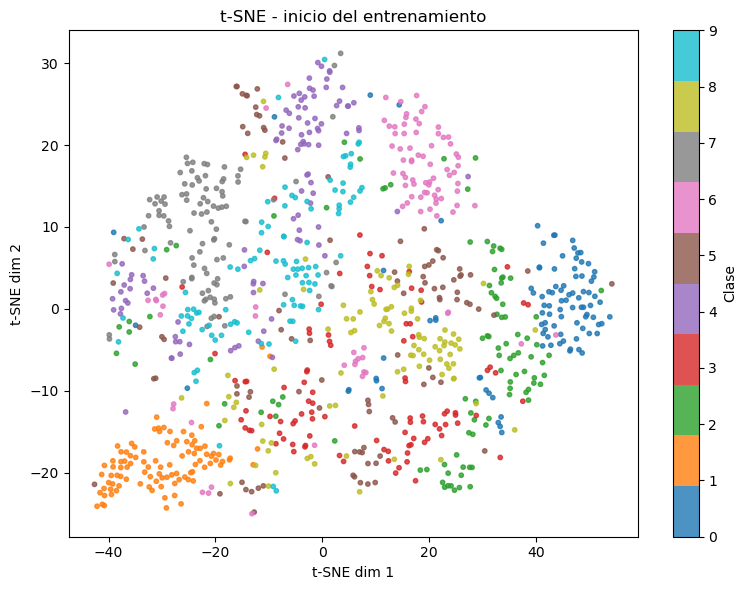

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

...

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

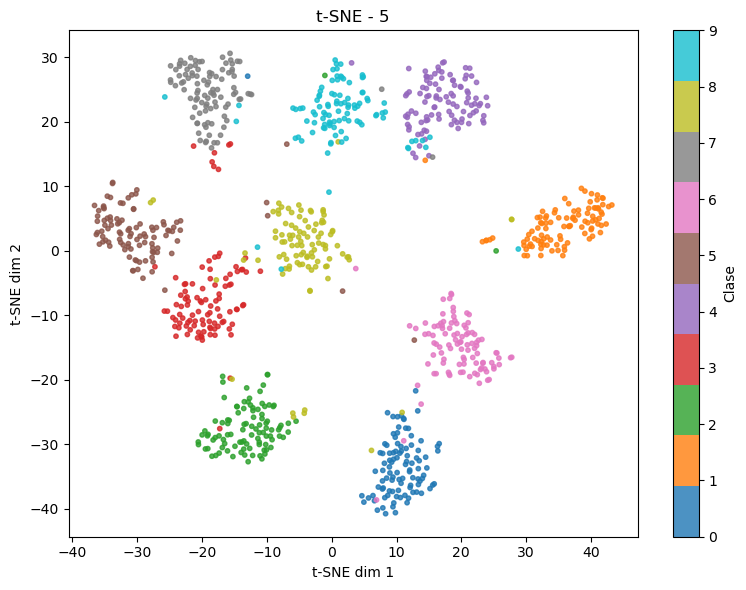

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

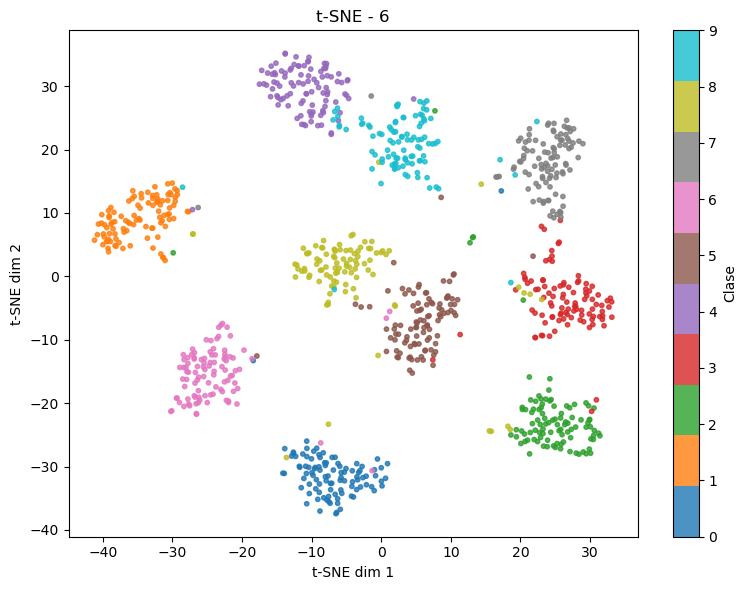

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
deterministic(config["xtra"]["seed"])
history = train_protonet(
    model=model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    episodes=episodes,
    tsne_images=mnist_vis_images,
    tsne_labels=mnist_vis_labels,
    tsne_dir="../images/tsne_protonet",
)

In [7]:
path = "../models/weights/protonet_mnist.pth"
model.save(path)

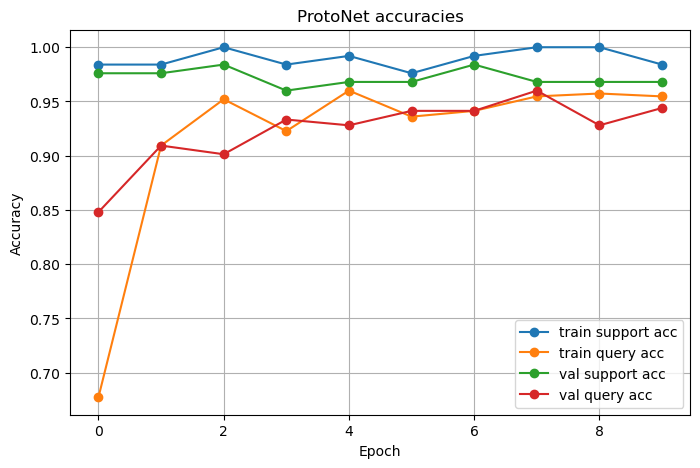

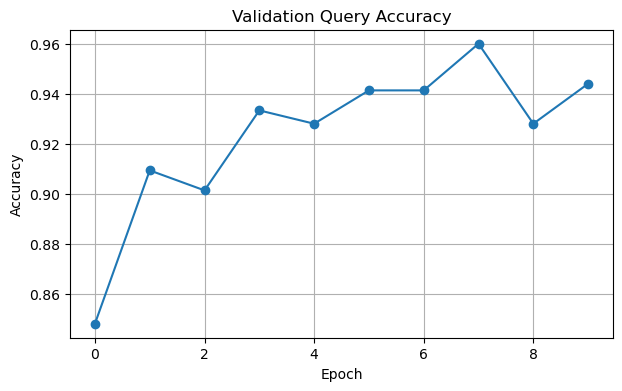

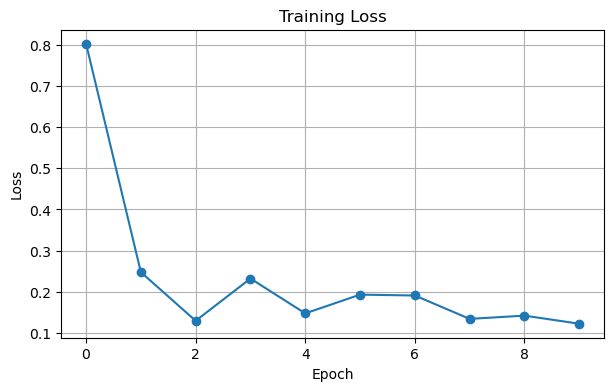

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_support_acc"], label="train support acc", marker="o")
plt.plot(history["train_query_acc"], label="train query acc", marker="o")
plt.plot(history["val_support_acc"], label="val support acc", marker="o")
plt.plot(history["val_query_acc"], label="val query acc", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ProtoNet accuracies")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_query_acc"], marker="o")
plt.title("Validation Query Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Eval

In [3]:
path = "../models/weights/protonet_mnist.pth"
experiment_parameters = config["experiment_1"]
in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]
encoder = ProtoNetEncoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
model = ProtoNet(encoder)
model.load(path, device)

In [ ]:
ks = [1, 2, 4, 8, 16]
q = 10
n_way = experiment_parameters["n_way"]
episodes = experiment_parameters["evalute_episodes"]

accuracies = {"Mnist": [], "Mnist-M": [], "Svhn": []}

data = "Mnist"
test_mnist_images, test_mnist_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Svhn"
test_svhn_images, test_svhn_labels = load_data("test", config[data]["dataset_output_dir"])

test_data = {"Mnist": (test_mnist_images, test_mnist_labels),
             "Mnist-M": (test_mnist_m_images, test_mnist_m_labels),
             "Svhn": (test_svhn_images, test_svhn_labels)}


K=1 Accuracy: Mnist=0.9040, Mnist-M=0.2834, Svhn=0.2138
K=2 Accuracy: Mnist=0.9456, Mnist-M=0.3172, Svhn=0.2184
K=4 Accuracy: Mnist=0.9644, Mnist-M=0.3414, Svhn=0.2216
K=8 Accuracy: Mnist=0.9724, Mnist-M=0.4064, Svhn=0.2332
K=16 Accuracy: Mnist=0.9728, Mnist-M=0.4296, Svhn=0.2362


In [ ]:
accuracies = evaluate_domains(model=model,test_data=test_data, n_way=n_way,
                              ks=ks, q=q, episodes=episodes, device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies['Svhn'][ks.index(k)]:.4f}")

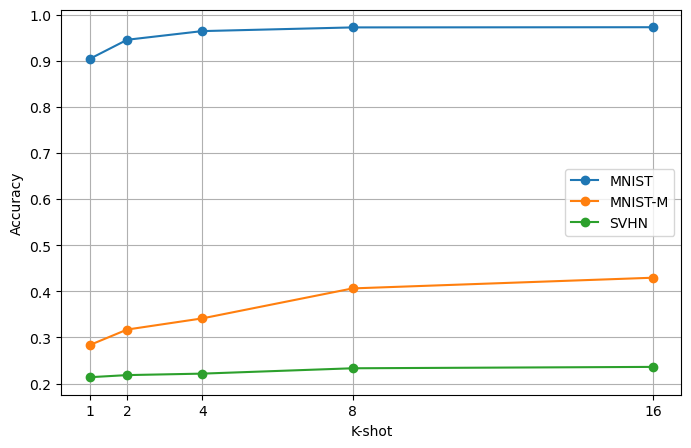

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(ks, accuracies["Mnist"], marker="o", label="MNIST")
plt.plot(ks, accuracies["Mnist-M"], marker="o", label="MNIST-M")
plt.plot(ks, accuracies["Svhn"], marker="o", label="SVHN")

plt.xlabel("K-shot")
plt.ylabel("Accuracy")
plt.xticks(ks)
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Lucio\AppData\Local\Temp\ipykernel_19196\1717712225.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


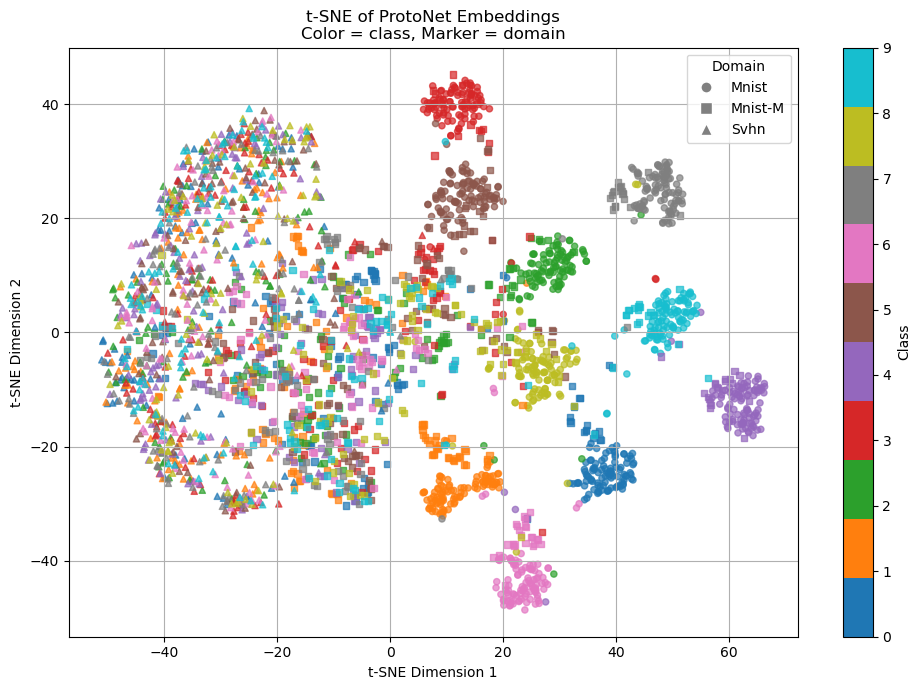

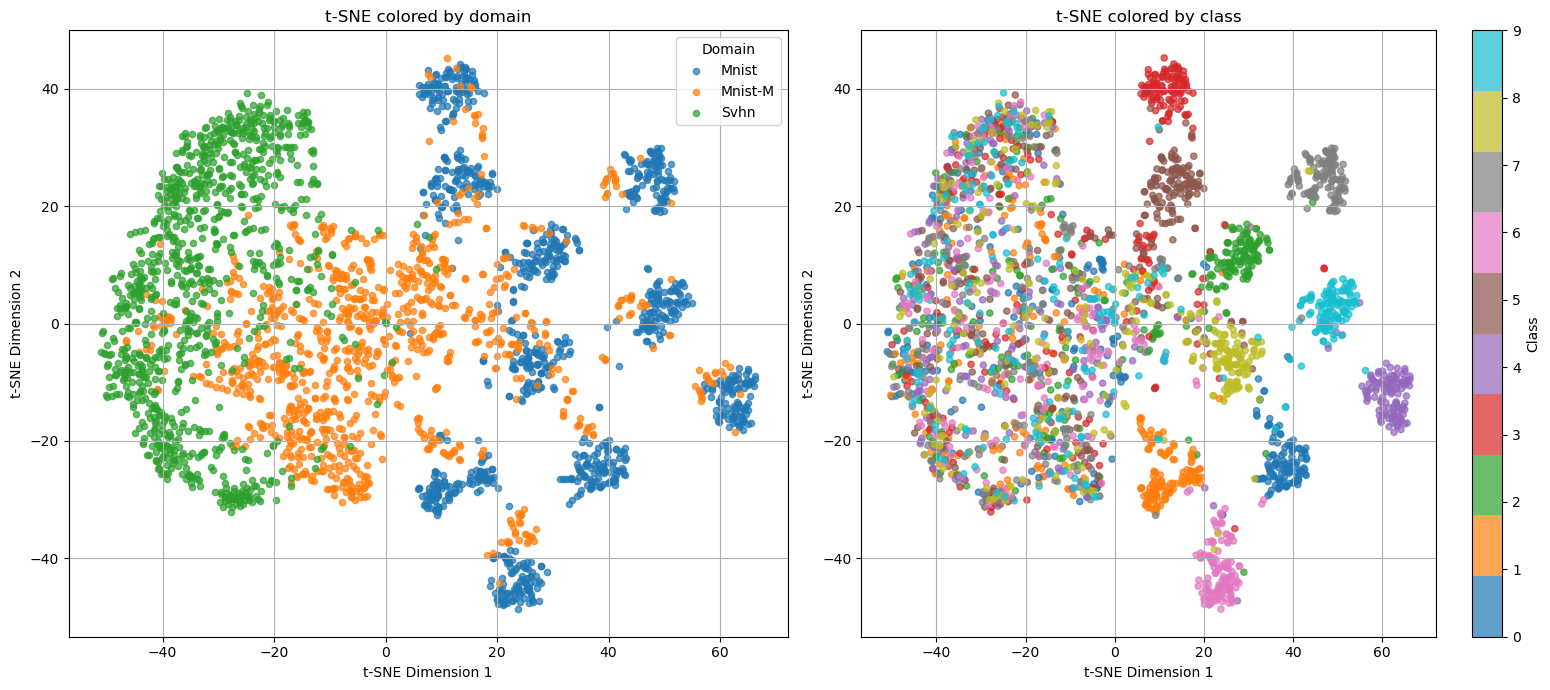

In [ ]:
samples_per_class = 100

fixed_images_labels = {}

for domain in test_data:
    images, labels = test_data[domain]
    fixed_images, fixed_labels = select_fixed_subset(
        images,
        labels,
        samples_per_class=samples_per_class,
        seed=config["xtra"]["seed"]
    )
    fixed_images_labels[domain] = (fixed_images, fixed_labels)

#embeddings
model.eval()
embeddings_labels = {}

with torch.no_grad():
    for domain in fixed_images_labels:
        images, labels = fixed_images_labels[domain]
        images = images.to(device)
        embeddings = model.encoder(images).cpu().numpy()
        labels = labels.cpu().numpy()
        embeddings_labels[domain] = (embeddings, labels)
all_embeddings = []
all_labels = []
all_domains = []

for domain in embeddings_labels:
    embeddings, labels = embeddings_labels[domain]
    all_embeddings.append(embeddings)
    all_labels.append(labels)
    all_domains.extend([domain] * len(labels))

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_domains = np.array(all_domains)

#tsne
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)
tsne_embeddings = tsne.fit_transform(all_embeddings)

#plot 1, class color, domain marker
fig, ax = plt.subplots(figsize=(10, 7))

markers = {
    "Mnist": "o",
    "Mnist-M": "s",
    "Svhn": "^"
}

cmap = plt.cm.get_cmap("tab10", 10)

for domain in np.unique(all_domains):
    domain_mask = all_domains == domain

    ax.scatter(
        tsne_embeddings[domain_mask, 0],
        tsne_embeddings[domain_mask, 1],
        c=all_labels[domain_mask],
        cmap=cmap,
        vmin=0,
        vmax=9,
        marker=markers[domain],
        alpha=0.7,
        s=20,
        label=domain
    )

ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title("t-SNE of ProtoNet Embeddings\nColor = class, Marker = domain")
ax.grid(True)

domain_legend = [
    Line2D([0], [0], marker=markers[d], color="w", label=d,
           markerfacecolor="gray", markersize=8, linestyle="None")
    for d in np.unique(all_domains)
]
ax.legend(handles=domain_legend, title="Domain")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=9))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, ticks=list(range(10)))
cbar.set_label("Class")

fig.tight_layout()
plt.show()

#plot 2, domain color and class color
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#subplot 1: domain color
domain_colors = {
    "Mnist": "tab:blue",
    "Mnist-M": "tab:orange",
    "Svhn": "tab:green"
}

for domain in np.unique(all_domains):
    domain_mask = all_domains == domain

    axes[0].scatter(
        tsne_embeddings[domain_mask, 0],
        tsne_embeddings[domain_mask, 1],
        color=domain_colors[domain],
        alpha=0.7,
        s=20,
        label=domain
    )

axes[0].set_title("t-SNE colored by domain")
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].grid(True)
axes[0].legend(title="Domain")

#subplot 2: class color
scatter = axes[1].scatter(
    tsne_embeddings[:, 0],
    tsne_embeddings[:, 1],
    c=all_labels,
    cmap=cmap,
    vmin=0,
    vmax=9,
    alpha=0.7,
    s=20
)

axes[1].set_title("t-SNE colored by class")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].grid(True)

cbar = fig.colorbar(scatter, ax=axes[1], ticks=list(range(10)))
cbar.set_label("Class")

fig.tight_layout()
plt.show()